### Carga de datos

In [1]:
import sys
sys.path.append('..')  # Si estás en notebooks/

from src.data.data_quality import analyze_data_quality, show_categorical_columns    

In [2]:
import pandas as pd
df = pd.read_csv('C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/raw/ofertas_relampago.csv', sep=',', encoding='latin-1')

In [3]:
df.shape

(48746, 13)

In [4]:
df.head()

,OFFER_START_DATE,OFFER_START_DTTM,OFFER_FINISH_DTTM,OFFER_TYPE,INVOLVED_STOCK,REMAINING_STOCK_AFTER_END,SOLD_AMOUNT,SOLD_QUANTITY,ORIGIN,SHIPPING_PAYMENT_TYPE,DOM_DOMAIN_AGG1,VERTICAL,DOMAIN_ID
0,2021-06-22,2021-06-22 16:00:00+00:00,2021-06-22 23:02:43+00:00,lightning_deal,4,-2,4.72,6.0,A,none,PETS FOOD,CPG,MLM-BIRD_FOODS
1,2021-06-22,2021-06-22 13:00:00+00:00,2021-06-22 19:00:02+00:00,lightning_deal,5,5,NaN,NaN,NaN,free_shipping,PET PRODUCTS,OTHERS,MLM-ANIMAL_AND_PET_PRODUCTS
2,2021-06-22,2021-06-22 07:00:00+00:00,2021-06-22 13:00:01+00:00,lightning_deal,15,12,10.73,3.0,NaN,none,COMPUTERS,CE,MLM-SPEAKERS
3,2021-06-22,2021-06-22 19:00:00+00:00,2021-06-23 01:36:12+00:00,lightning_deal,15,13,7.03,2.0,NaN,none,COMPUTERS,CE,MLM-HEADPHONES
4,2021-06-22,2021-06-22 13:00:00+00:00,2021-06-22 15:48:12+00:00,lightning_deal,15,0,39.65,15.0,NaN,none,COMPUTERS,CE,MLM-HEADPHONES


In [20]:
df['ORIGIN'].value_counts()

ORIGIN
A    11316
Name: count, dtype: int64

In [5]:

quality_report = analyze_data_quality(df)
print(quality_report)

categorical_report = show_categorical_columns(df)
if categorical_report is not None:
    print(categorical_report)

                     Columna      Tipo  Porcentaje_Nulos  Porcentaje_Ceros  \
0             INVOLVED_STOCK  Numérica              0.00              0.00   
1  REMAINING_STOCK_AFTER_END  Numérica              0.00              6.13   
2                SOLD_AMOUNT  Numérica             49.58              0.00   
3              SOLD_QUANTITY  Numérica             49.58              0.00   

   Porcentaje_Infinitos  Porcentaje_Outliers_IQR  Total_Registros  \
0                   0.0                     9.12            48746   
1                   0.0                     8.52            48746   
2                   0.0                    12.01            48746   
3                   0.0                    11.79            48746   

   Registros_No_Nulos  
0               48746  
1               48746  
2               24579  
3               24579  
                 Columna              Tipo  Valores_Únicos  \
0       OFFER_START_DATE  Categórica/Texto              61   
1       OFFER_START

In [8]:
quality_report

,Columna,Tipo,Porcentaje_Nulos,Porcentaje_Ceros,Porcentaje_Infinitos,Porcentaje_Outliers_IQR,Total_Registros,Registros_No_Nulos
0,INVOLVED_STOCK,Numérica,0.00,0.00,0.0,9.12,48746,48746
1,REMAINING_STOCK_AFTER_END,Numérica,0.00,6.13,0.0,8.52,48746,48746
2,SOLD_AMOUNT,Numérica,49.58,0.00,0.0,12.01,48746,24579
3,SOLD_QUANTITY,Numérica,49.58,0.00,0.0,11.79,48746,24579


In [9]:
categorical_report

,Columna,Tipo,Valores_Únicos,Ejemplo_Valor
0,OFFER_START_DATE,Categórica/Texto,61,2021-06-22
1,OFFER_START_DTTM,Categórica/Texto,783,2021-06-22 16:00:00+00:00
2,OFFER_FINISH_DTTM,Categórica/Texto,7578,2021-06-22 23:02:43+00:00
3,OFFER_TYPE,Categórica/Texto,1,lightning_deal
4,ORIGIN,Categórica/Texto,1,A
5,SHIPPING_PAYMENT_TYPE,Categórica/Texto,2,none
6,DOM_DOMAIN_AGG1,Categórica/Texto,36,PETS FOOD
7,VERTICAL,Categórica/Texto,9,CPG
8,DOMAIN_ID,Categórica/Texto,1266,MLM-BIRD_FOODS


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [10]:
# ============================================================================
# 1. PREPARACIÓN DE DATOS
# ============================================================================

# Convertir fechas
df['OFFER_START_DATE'] = pd.to_datetime(df['OFFER_START_DATE'])
df['OFFER_START_DTTM'] = pd.to_datetime(df['OFFER_START_DTTM'])
df['OFFER_FINISH_DTTM'] = pd.to_datetime(df['OFFER_FINISH_DTTM'])

# Crear variables derivadas
df['offer_duration_hours'] = (df['OFFER_FINISH_DTTM'] - df['OFFER_START_DTTM']).dt.total_seconds() / 3600
df['offer_hour'] = df['OFFER_START_DTTM'].dt.hour
df['offer_day_of_week'] = df['OFFER_START_DTTM'].dt.day_name()
df['offer_month'] = df['OFFER_START_DTTM'].dt.month
df['offer_year'] = df['OFFER_START_DTTM'].dt.year
df['sell_through_rate'] = (df['SOLD_QUANTITY'] / df['INVOLVED_STOCK']) * 100
df['avg_price'] = df['SOLD_AMOUNT'] / df['SOLD_QUANTITY']
df['stock_exhausted'] = (df['REMAINING_STOCK_AFTER_END'] <= 0).astype(int)

print("✅ Datos preparados")
print(f"Shape: {df.shape}")
print(f"Periodo: {df['OFFER_START_DATE'].min()} a {df['OFFER_START_DATE'].max()}")

✅ Datos preparados
Shape: (48746, 21)
Periodo: 2021-06-01 00:00:00 a 2021-07-31 00:00:00



CAPÍTULO 1: EL PANORAMA GENERAL

📊 MÉTRICAS GENERALES:
  • Total de ofertas: 48,746
  • Ingresos totales: $1,258,663.50
  • Unidades vendidas: 266,708
  • Sell-through rate promedio: 41.0%
  • Ofertas que agotaron stock: 8.7%


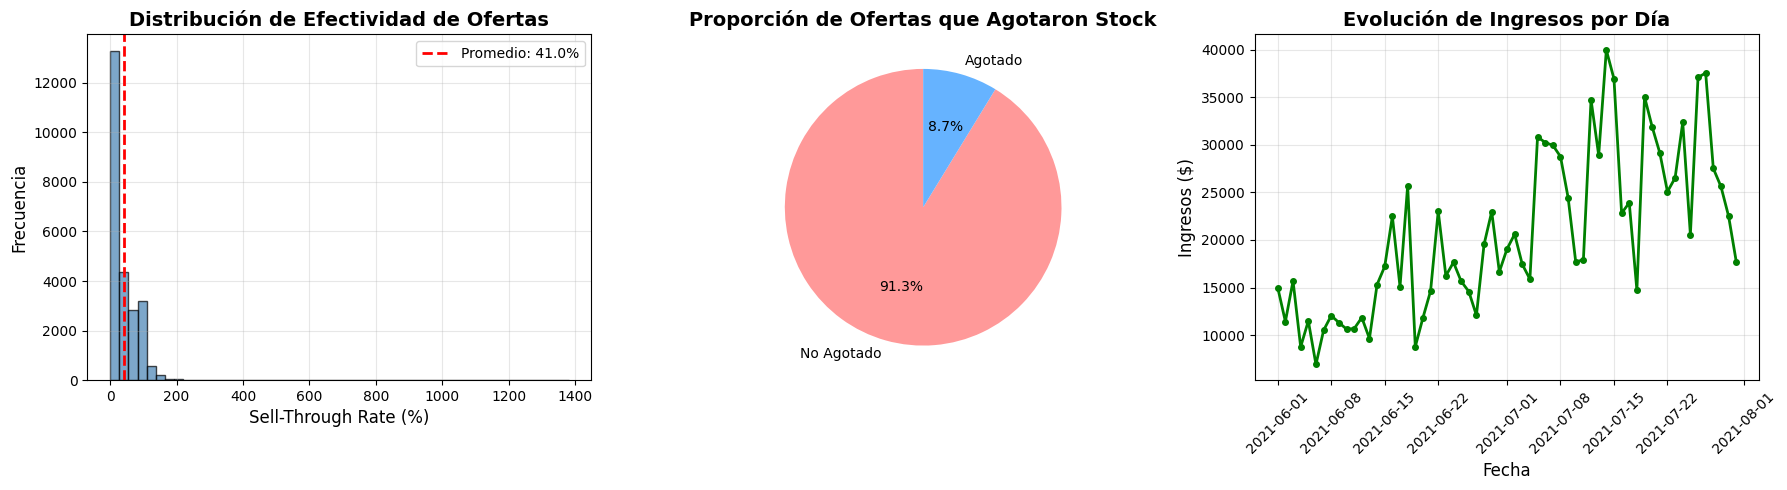


💡 INSIGHT 1: El sell-through rate promedio nos indica qué tan bien estamos dimensionando nuestro inventario.


In [11]:
# ============================================================================
# 2. CAPÍTULO 1: EL PANORAMA GENERAL - ¿Qué tan efectivas son nuestras ofertas?
# ============================================================================

print("\n" + "="*80)
print("CAPÍTULO 1: EL PANORAMA GENERAL")
print("="*80)

# Métricas clave
total_offers = len(df)
total_revenue = df['SOLD_AMOUNT'].sum()
total_units = df['SOLD_QUANTITY'].sum()
avg_sell_through = df['sell_through_rate'].mean()
exhausted_pct = (df['stock_exhausted'].sum() / total_offers) * 100

print(f"\n📊 MÉTRICAS GENERALES:")
print(f"  • Total de ofertas: {total_offers:,}")
print(f"  • Ingresos totales: ${total_revenue:,.2f}")
print(f"  • Unidades vendidas: {total_units:,.0f}")
print(f"  • Sell-through rate promedio: {avg_sell_through:.1f}%")
print(f"  • Ofertas que agotaron stock: {exhausted_pct:.1f}%")

# Visualización: Distribución de sell-through rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribución de sell-through
axes[0].hist(df['sell_through_rate'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(avg_sell_through, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_sell_through:.1f}%')
axes[0].set_xlabel('Sell-Through Rate (%)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Efectividad de Ofertas', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Stock agotado vs no agotado
stock_counts = df['stock_exhausted'].value_counts()
axes[1].pie(stock_counts, labels=['No Agotado', 'Agotado'], autopct='%1.1f%%', 
            colors=['#ff9999', '#66b3ff'], startangle=90)
axes[1].set_title('Proporción de Ofertas que Agotaron Stock', fontsize=14, fontweight='bold')

# Gráfico 3: Revenue por día
daily_revenue = df.groupby('OFFER_START_DATE')['SOLD_AMOUNT'].sum().reset_index()
axes[2].plot(daily_revenue['OFFER_START_DATE'], daily_revenue['SOLD_AMOUNT'], 
             color='green', linewidth=2, marker='o', markersize=4)
axes[2].set_xlabel('Fecha', fontsize=12)
axes[2].set_ylabel('Ingresos ($)', fontsize=12)
axes[2].set_title('Evolución de Ingresos por Día', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT 1: El sell-through rate promedio nos indica qué tan bien estamos dimensionando nuestro inventario.")


CAPÍTULO 2: TIMING ES TODO - ¿Cuándo vender?

⏰ ANÁLISIS TEMPORAL:
  • Mejor hora para lanzar ofertas: 13:00 hrs
  • Mejor día de la semana: Tuesday


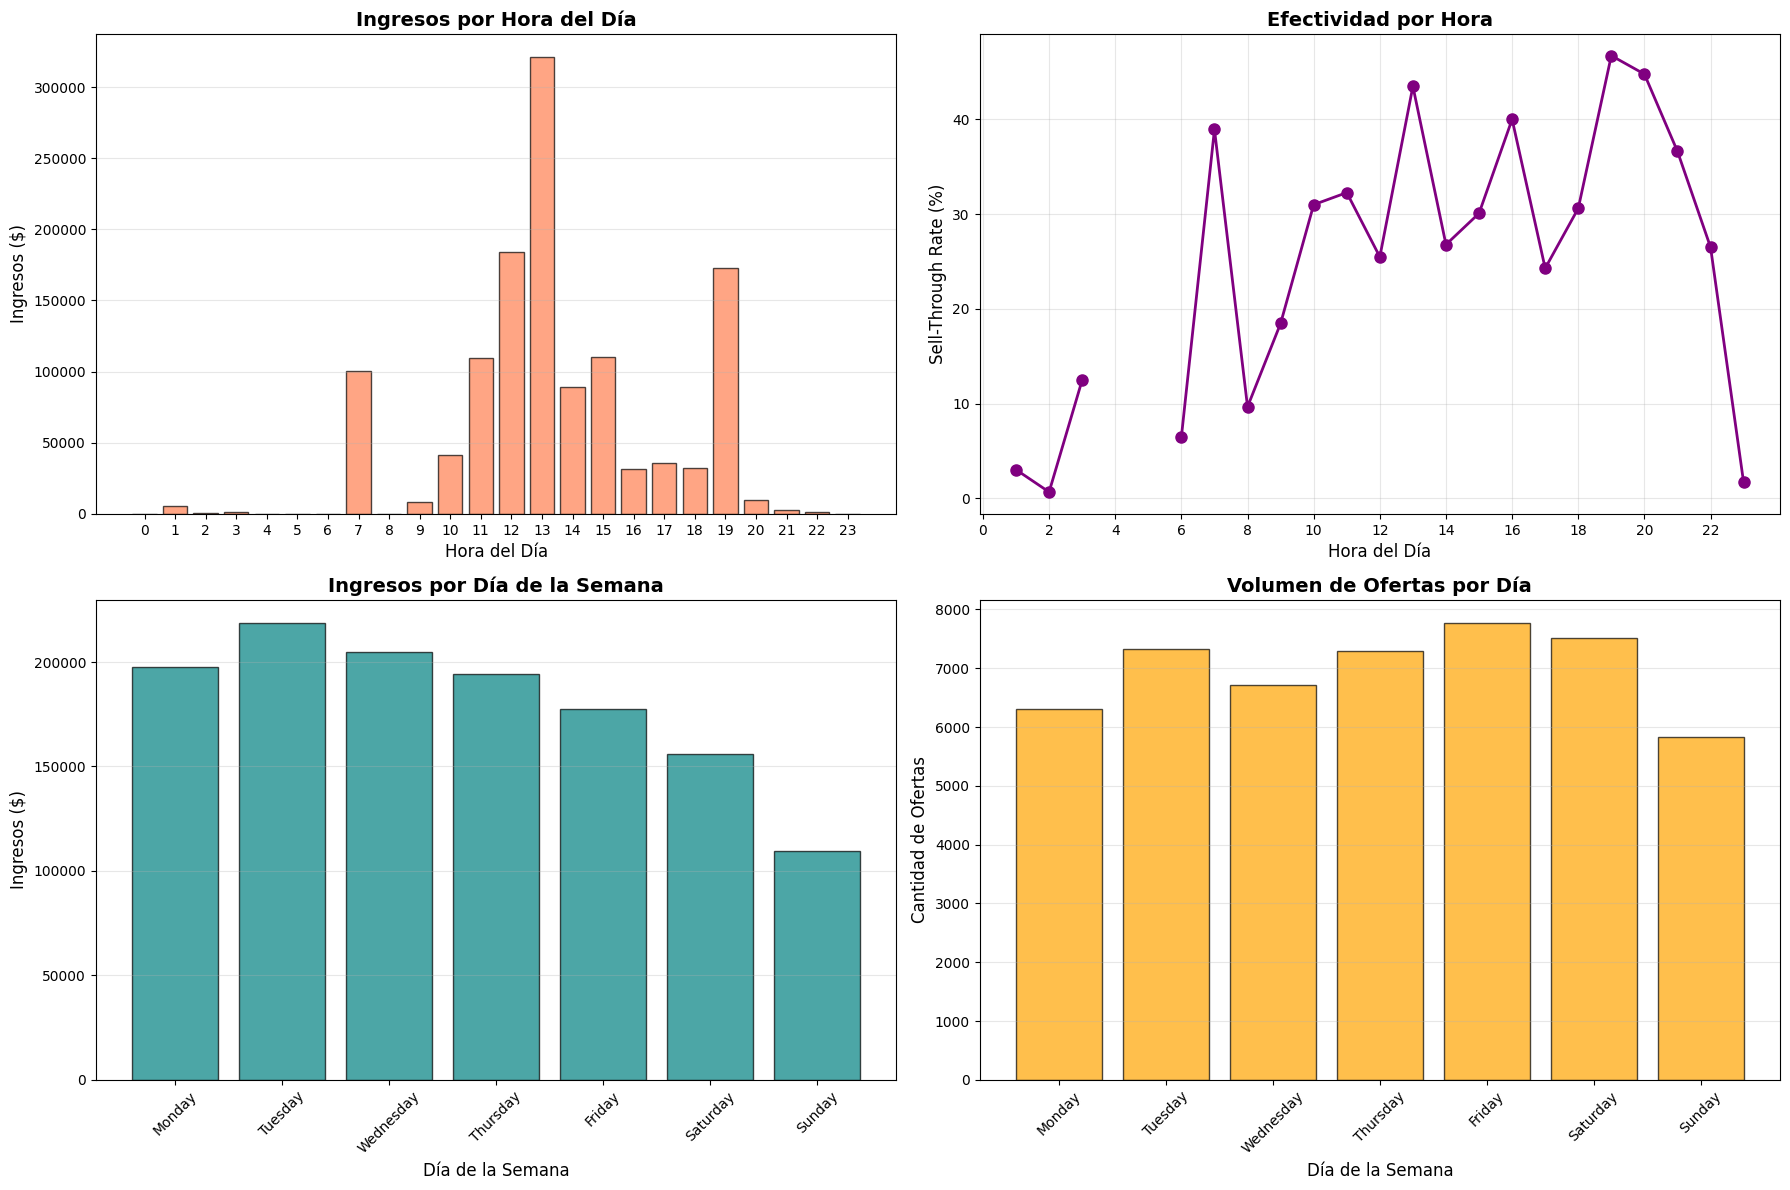


💡 INSIGHT 2: Identificar las ventanas de tiempo óptimas puede aumentar significativamente el sell-through.


In [12]:
# ============================================================================
# 3. CAPÍTULO 2: TIMING ES TODO - ¿Cuándo vender?
# ============================================================================

print("\n" + "="*80)
print("CAPÍTULO 2: TIMING ES TODO - ¿Cuándo vender?")
print("="*80)

# Análisis por hora del día
hourly_performance = df.groupby('offer_hour').agg({
    'SOLD_AMOUNT': 'sum',
    'SOLD_QUANTITY': 'sum',
    'sell_through_rate': 'mean'
}).reset_index()

# Análisis por día de la semana
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_performance = df.groupby('offer_day_of_week').agg({
    'SOLD_AMOUNT': 'sum',
    'SOLD_QUANTITY': 'sum',
    'sell_through_rate': 'mean',
    'OFFER_START_DATE': 'count'
}).reset_index()
weekly_performance['offer_day_of_week'] = pd.Categorical(
    weekly_performance['offer_day_of_week'], categories=weekday_order, ordered=True
)
weekly_performance = weekly_performance.sort_values('offer_day_of_week')

print(f"\n⏰ ANÁLISIS TEMPORAL:")
best_hour = hourly_performance.loc[hourly_performance['SOLD_AMOUNT'].idxmax(), 'offer_hour']
best_day = weekly_performance.loc[weekly_performance['SOLD_AMOUNT'].idxmax(), 'offer_day_of_week']
print(f"  • Mejor hora para lanzar ofertas: {int(best_hour)}:00 hrs")
print(f"  • Mejor día de la semana: {best_day}")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Gráfico 1: Ingresos por hora
axes[0, 0].bar(hourly_performance['offer_hour'], hourly_performance['SOLD_AMOUNT'], 
               color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Hora del Día', fontsize=12)
axes[0, 0].set_ylabel('Ingresos ($)', fontsize=12)
axes[0, 0].set_title('Ingresos por Hora del Día', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(range(24))
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Sell-through por hora
axes[0, 1].plot(hourly_performance['offer_hour'], hourly_performance['sell_through_rate'], 
                color='purple', linewidth=2, marker='o', markersize=8)
axes[0, 1].set_xlabel('Hora del Día', fontsize=12)
axes[0, 1].set_ylabel('Sell-Through Rate (%)', fontsize=12)
axes[0, 1].set_title('Efectividad por Hora', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].grid(alpha=0.3)

# Gráfico 3: Ingresos por día de la semana
axes[1, 0].bar(range(len(weekly_performance)), weekly_performance['SOLD_AMOUNT'], 
               color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Día de la Semana', fontsize=12)
axes[1, 0].set_ylabel('Ingresos ($)', fontsize=12)
axes[1, 0].set_title('Ingresos por Día de la Semana', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(range(len(weekly_performance)))
axes[1, 0].set_xticklabels(weekly_performance['offer_day_of_week'], rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Gráfico 4: Número de ofertas por día
axes[1, 1].bar(range(len(weekly_performance)), weekly_performance['OFFER_START_DATE'], 
               color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Día de la Semana', fontsize=12)
axes[1, 1].set_ylabel('Cantidad de Ofertas', fontsize=12)
axes[1, 1].set_title('Volumen de Ofertas por Día', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(range(len(weekly_performance)))
axes[1, 1].set_xticklabels(weekly_performance['offer_day_of_week'], rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT 2: Identificar las ventanas de tiempo óptimas puede aumentar significativamente el sell-through.")


CAPÍTULO 3: TIPOS DE OFERTAS - ¿Qué formato funciona mejor?

🎯 RENDIMIENTO POR TIPO DE OFERTA:
    OFFER_TYPE  SOLD_AMOUNT_sum  SOLD_AMOUNT_mean  SOLD_QUANTITY_sum  SOLD_QUANTITY_mean  sell_through_rate_mean  stock_exhausted_mean  offer_duration_hours_mean  total_offers
lightning_deal        1258663.5         51.208898           266708.0           10.851052               41.000412              0.087433                   5.708344         48746


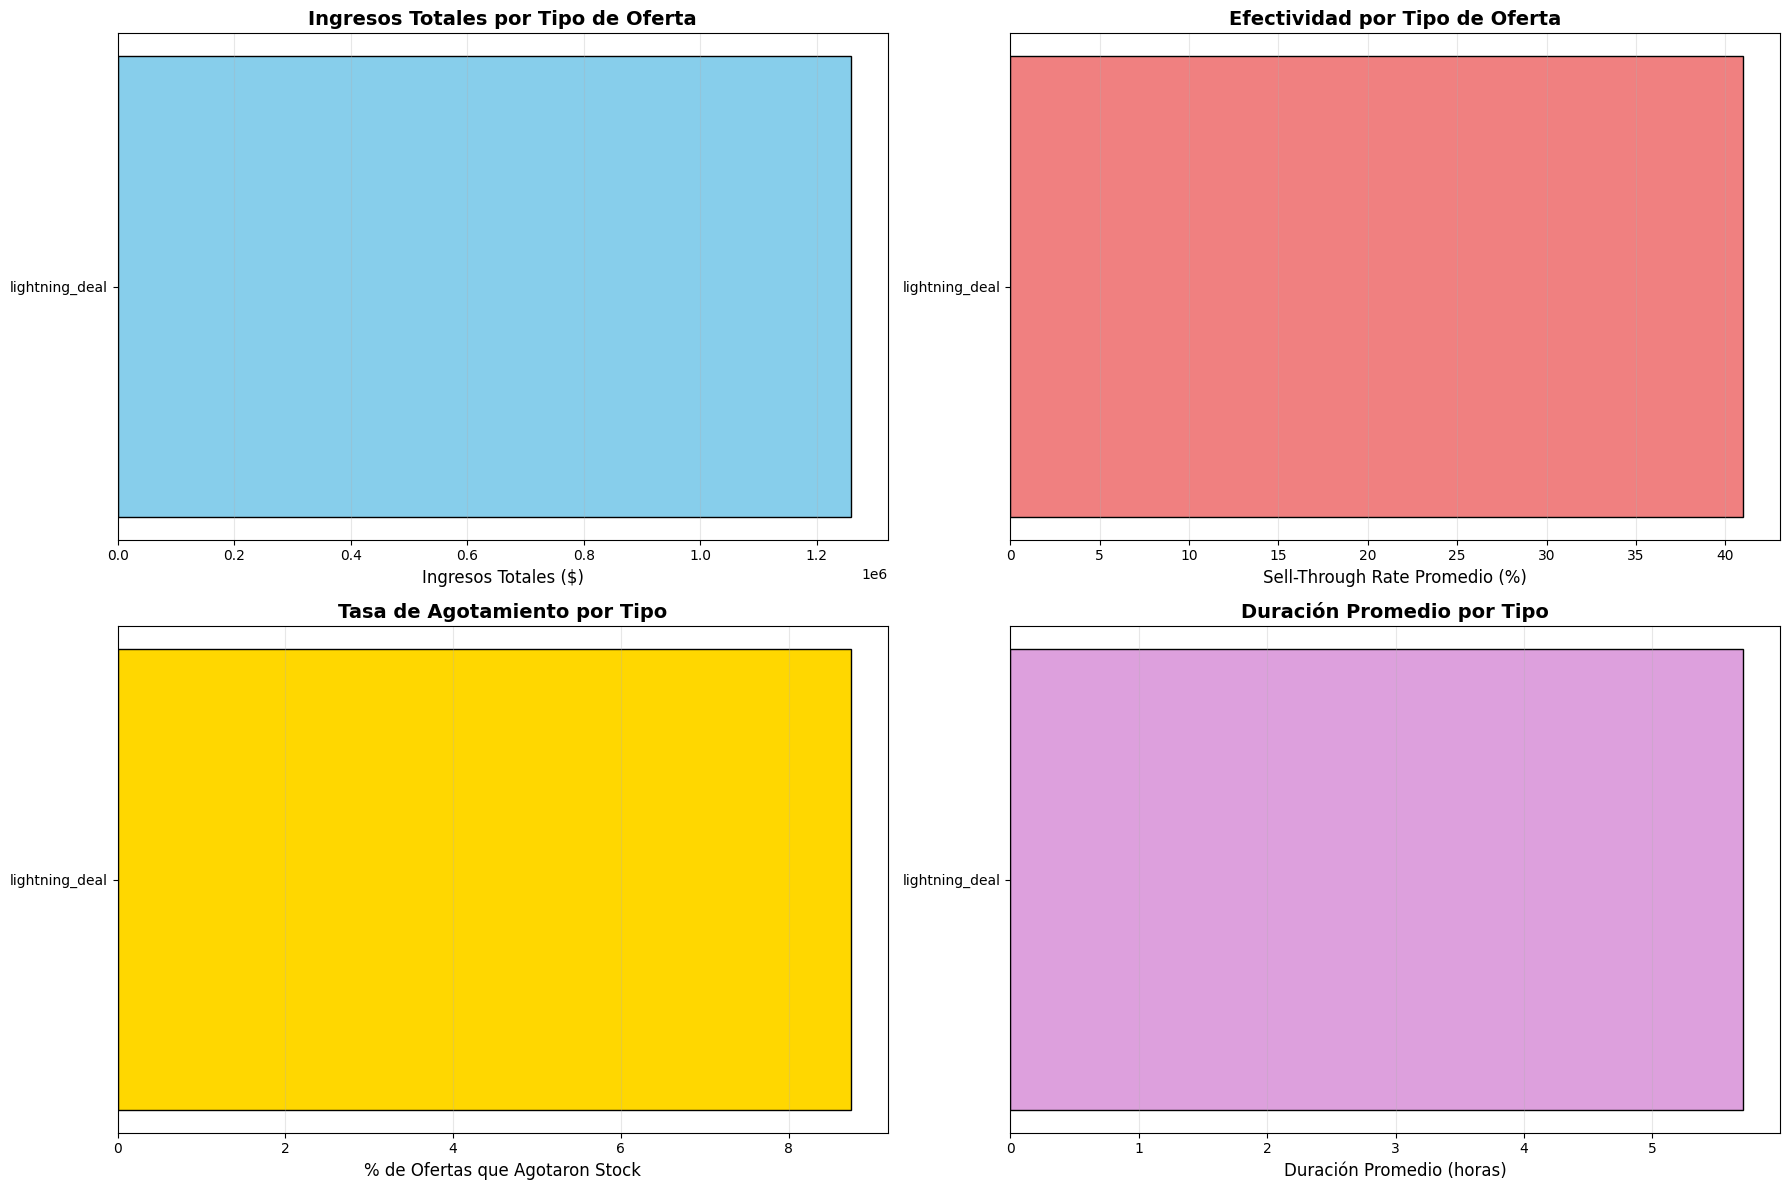


💡 INSIGHT 3: Diferentes tipos de ofertas tienen diferentes perfiles de rendimiento.


In [13]:
# ============================================================================
# 4. CAPÍTULO 3: TIPOS DE OFERTAS - ¿Qué formato funciona mejor?
# ============================================================================

print("\n" + "="*80)
print("CAPÍTULO 3: TIPOS DE OFERTAS - ¿Qué formato funciona mejor?")
print("="*80)

# Análisis por tipo de oferta
offer_type_analysis = df.groupby('OFFER_TYPE').agg({
    'SOLD_AMOUNT': ['sum', 'mean'],
    'SOLD_QUANTITY': ['sum', 'mean'],
    'sell_through_rate': 'mean',
    'stock_exhausted': 'mean',
    'offer_duration_hours': 'mean',
    'OFFER_START_DATE': 'count'
}).reset_index()

offer_type_analysis.columns = ['_'.join(col).strip('_') for col in offer_type_analysis.columns]
offer_type_analysis = offer_type_analysis.rename(columns={'OFFER_START_DATE_count': 'total_offers'})

print(f"\n🎯 RENDIMIENTO POR TIPO DE OFERTA:")
print(offer_type_analysis.to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Gráfico 1: Ingresos totales por tipo
axes[0, 0].barh(offer_type_analysis['OFFER_TYPE'], offer_type_analysis['SOLD_AMOUNT_sum'], 
                color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Ingresos Totales ($)', fontsize=12)
axes[0, 0].set_title('Ingresos Totales por Tipo de Oferta', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Gráfico 2: Sell-through rate por tipo
axes[0, 1].barh(offer_type_analysis['OFFER_TYPE'], offer_type_analysis['sell_through_rate_mean'], 
                color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Sell-Through Rate Promedio (%)', fontsize=12)
axes[0, 1].set_title('Efectividad por Tipo de Oferta', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Gráfico 3: Proporción de stock agotado por tipo
axes[1, 0].barh(offer_type_analysis['OFFER_TYPE'], offer_type_analysis['stock_exhausted_mean'] * 100, 
                color='gold', edgecolor='black')
axes[1, 0].set_xlabel('% de Ofertas que Agotaron Stock', fontsize=12)
axes[1, 0].set_title('Tasa de Agotamiento por Tipo', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Gráfico 4: Duración promedio por tipo
axes[1, 1].barh(offer_type_analysis['OFFER_TYPE'], offer_type_analysis['offer_duration_hours_mean'], 
                color='plum', edgecolor='black')
axes[1, 1].set_xlabel('Duración Promedio (horas)', fontsize=12)
axes[1, 1].set_title('Duración Promedio por Tipo', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT 3: Diferentes tipos de ofertas tienen diferentes perfiles de rendimiento.")


CAPÍTULO 4: GEOGRAFÍA Y LOGÍSTICA

📍 ANÁLISIS POR ORIGEN:
ORIGIN  SOLD_AMOUNT  SOLD_QUANTITY  sell_through_rate  total_offers
     A    838478.52       187970.0          29.817997         11316

🚚 ANÁLISIS POR TIPO DE ENVÍO:
SHIPPING_PAYMENT_TYPE  SOLD_AMOUNT  SOLD_QUANTITY  sell_through_rate  total_offers
        free_shipping    748536.12        64347.0          34.588511         26658
                 none    510127.38       202361.0          46.857730         22088


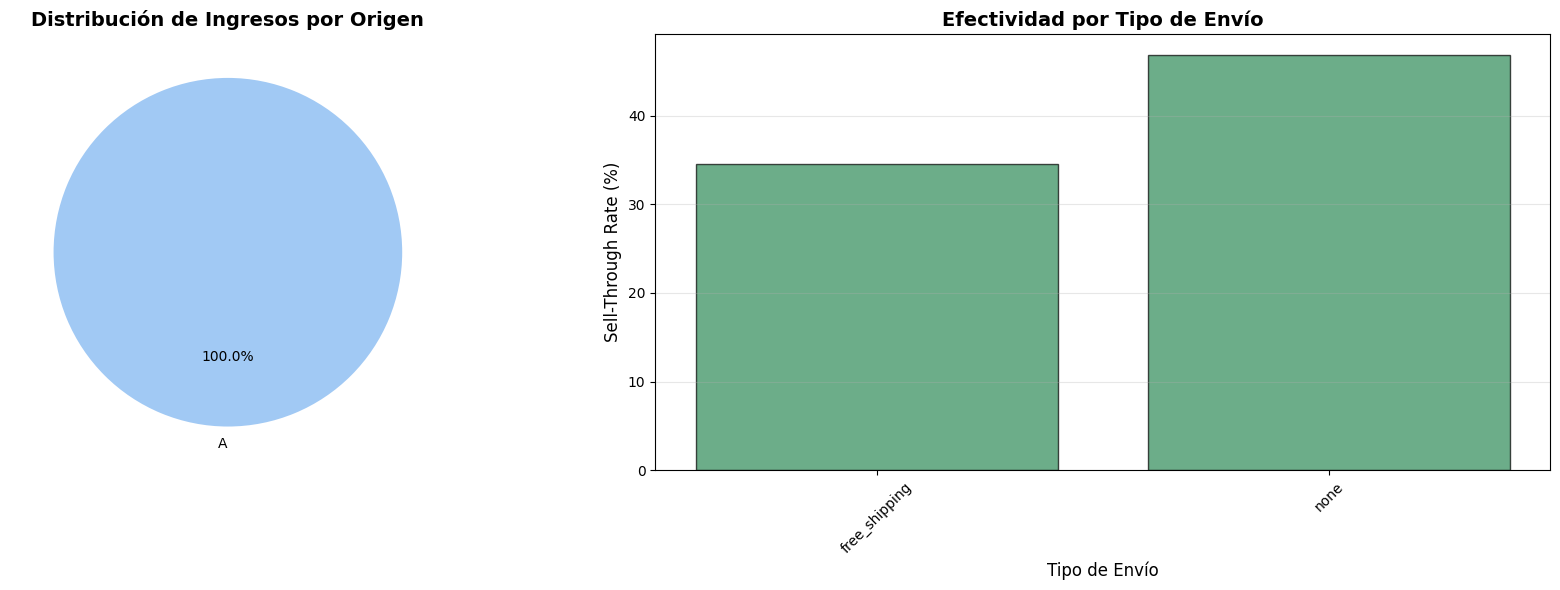


💡 INSIGHT 4: La estrategia de envío impacta directamente en la conversión.


In [15]:
# ============================================================================
# 5. CAPÍTULO 4: GEOGRAFÍA Y LOGÍSTICA - Origen y envío
# ============================================================================

print("\n" + "="*80)
print("CAPÍTULO 4: GEOGRAFÍA Y LOGÍSTICA")
print("="*80)

# Análisis por origen
origin_analysis = df.groupby('ORIGIN').agg({
    'SOLD_AMOUNT': 'sum',
    'SOLD_QUANTITY': 'sum',
    'sell_through_rate': 'mean',
    'OFFER_START_DATE': 'count'
}).reset_index().rename(columns={'OFFER_START_DATE': 'total_offers'})

# Análisis por tipo de envío
shipping_analysis = df.groupby('SHIPPING_PAYMENT_TYPE').agg({
    'SOLD_AMOUNT': 'sum',
    'SOLD_QUANTITY': 'sum',
    'sell_through_rate': 'mean',
    'OFFER_START_DATE': 'count'
}).reset_index().rename(columns={'OFFER_START_DATE': 'total_offers'})

print(f"\n📍 ANÁLISIS POR ORIGEN:")
print(origin_analysis.to_string(index=False))

print(f"\n🚚 ANÁLISIS POR TIPO DE ENVÍO:")
print(shipping_analysis.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Ingresos por origen
axes[0].pie(origin_analysis['SOLD_AMOUNT'], labels=origin_analysis['ORIGIN'], 
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[0].set_title('Distribución de Ingresos por Origen', fontsize=14, fontweight='bold')

# Gráfico 2: Sell-through por tipo de envío
axes[1].bar(shipping_analysis['SHIPPING_PAYMENT_TYPE'], shipping_analysis['sell_through_rate'], 
            color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Tipo de Envío', fontsize=12)
axes[1].set_ylabel('Sell-Through Rate (%)', fontsize=12)
axes[1].set_title('Efectividad por Tipo de Envío', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT 4: La estrategia de envío impacta directamente en la conversión.")


CAPÍTULO 5: CATEGORÍAS GANADORAS

🏆 TOP 10 VERTICALES POR INGRESOS:
       VERTICAL  SOLD_AMOUNT  sell_through_rate  stock_exhausted  total_offers
BEAUTY & HEALTH    547427.27          45.678883         0.116783          7150
             CE    362787.94          39.002030         0.106154          8629
HOME & INDUSTRY    155518.68          41.187685         0.086913         11011
   APP & SPORTS    131101.36          38.245764         0.069632         13241
            ACC     26819.98          46.052228         0.101438          2573
            CPG     16787.68          44.596755         0.090273          2714
          T & B     14302.78          36.227014         0.035823          2624
  ENTERTAINMENT      1988.57          35.978464         0.040000           525
         OTHERS      1929.24          35.210751         0.039427           279


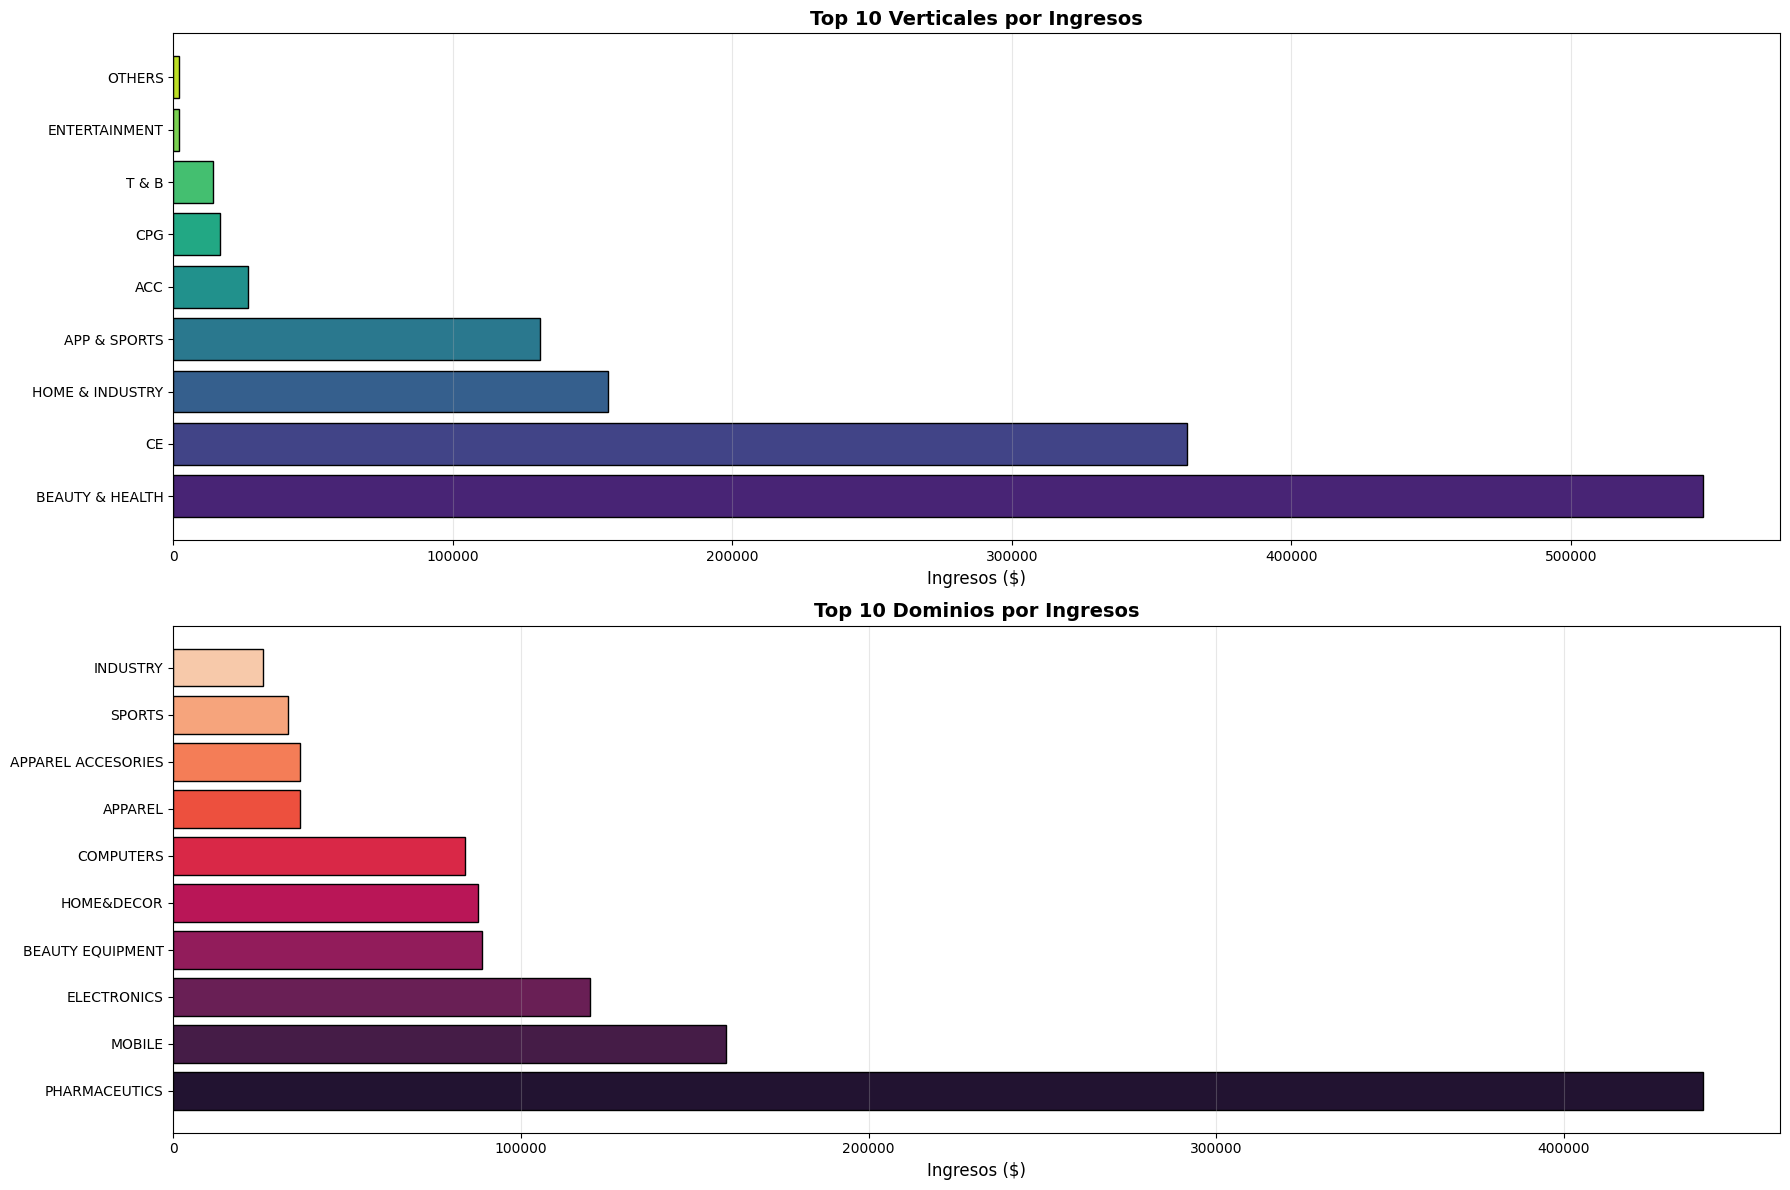


💡 INSIGHT 5: Algunas categorías son naturalmente más propensas al éxito en ofertas flash.


In [16]:
# ============================================================================
# 6. CAPÍTULO 5: CATEGORÍAS GANADORAS - Vertical y dominio
# ============================================================================

print("\n" + "="*80)
print("CAPÍTULO 5: CATEGORÍAS GANADORAS")
print("="*80)

# Top verticales por ingresos
top_verticals = df.groupby('VERTICAL').agg({
    'SOLD_AMOUNT': 'sum',
    'sell_through_rate': 'mean',
    'stock_exhausted': 'mean',
    'OFFER_START_DATE': 'count'
}).reset_index().rename(columns={'OFFER_START_DATE': 'total_offers'})
top_verticals = top_verticals.sort_values('SOLD_AMOUNT', ascending=False).head(10)

# Top dominios agregados
top_domains = df.groupby('DOM_DOMAIN_AGG1').agg({
    'SOLD_AMOUNT': 'sum',
    'sell_through_rate': 'mean',
    'OFFER_START_DATE': 'count'
}).reset_index().rename(columns={'OFFER_START_DATE': 'total_offers'})
top_domains = top_domains.sort_values('SOLD_AMOUNT', ascending=False).head(10)

print(f"\n🏆 TOP 10 VERTICALES POR INGRESOS:")
print(top_verticals.to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Gráfico 1: Top verticales
axes[0].barh(range(len(top_verticals)), top_verticals['SOLD_AMOUNT'], 
             color=sns.color_palette('viridis', len(top_verticals)), edgecolor='black')
axes[0].set_yticks(range(len(top_verticals)))
axes[0].set_yticklabels(top_verticals['VERTICAL'])
axes[0].set_xlabel('Ingresos ($)', fontsize=12)
axes[0].set_title('Top 10 Verticales por Ingresos', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: Top dominios
axes[1].barh(range(len(top_domains)), top_domains['SOLD_AMOUNT'], 
             color=sns.color_palette('rocket', len(top_domains)), edgecolor='black')
axes[1].set_yticks(range(len(top_domains)))
axes[1].set_yticklabels(top_domains['DOM_DOMAIN_AGG1'])
axes[1].set_xlabel('Ingresos ($)', fontsize=12)
axes[1].set_title('Top 10 Dominios por Ingresos', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT 5: Algunas categorías son naturalmente más propensas al éxito en ofertas flash.")


CAPÍTULO 6: PRICING Y COMPORTAMIENTO DE COMPRA

💰 ANÁLISIS POR SEGMENTO DE PRECIO:
price_segment  SOLD_QUANTITY  SOLD_AMOUNT  sell_through_rate  stock_exhausted
     Muy Bajo        76409.0    118957.68          53.736938         0.253304
         Bajo        92732.0    249699.56          45.721235         0.193666
        Medio        59447.0    237069.88          39.599670         0.150347
         Alto        18368.0    122144.18          34.944054         0.130391
     Muy Alto        19752.0    530792.20          30.978798         0.108421


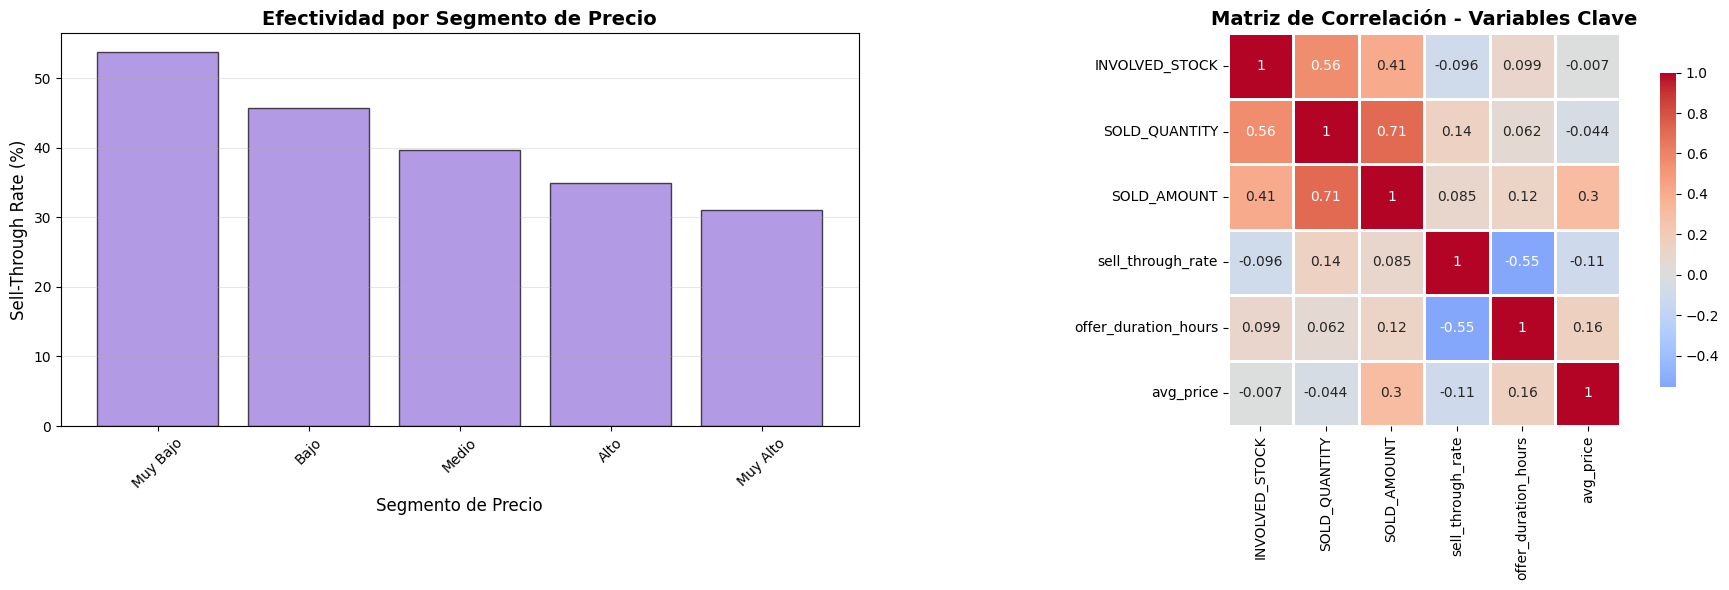


💡 INSIGHT 6: El precio impacta tanto en el volumen como en la efectividad de las ofertas.


In [17]:
# ============================================================================
# 7. CAPÍTULO 6: PRICING Y COMPORTAMIENTO DE COMPRA
# ============================================================================

print("\n" + "="*80)
print("CAPÍTULO 6: PRICING Y COMPORTAMIENTO DE COMPRA")
print("="*80)

# Análisis de precios
price_segments = pd.qcut(df['avg_price'], q=5, labels=['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'])
df['price_segment'] = price_segments

price_analysis = df.groupby('price_segment').agg({
    'SOLD_QUANTITY': 'sum',
    'SOLD_AMOUNT': 'sum',
    'sell_through_rate': 'mean',
    'stock_exhausted': 'mean'
}).reset_index()

print(f"\n💰 ANÁLISIS POR SEGMENTO DE PRECIO:")
print(price_analysis.to_string(index=False))

# Correlación entre variables clave
correlation_vars = ['INVOLVED_STOCK', 'SOLD_QUANTITY', 'SOLD_AMOUNT', 
                    'sell_through_rate', 'offer_duration_hours', 'avg_price']
correlation_matrix = df[correlation_vars].corr()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Sell-through por segmento de precio
axes[0].bar(price_analysis['price_segment'], price_analysis['sell_through_rate'], 
            color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Segmento de Precio', fontsize=12)
axes[0].set_ylabel('Sell-Through Rate (%)', fontsize=12)
axes[0].set_title('Efectividad por Segmento de Precio', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Matriz de correlación
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Matriz de Correlación - Variables Clave', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT 6: El precio impacta tanto en el volumen como en la efectividad de las ofertas.")


CAPÍTULO 7: OPTIMIZACIÓN DE STOCK

📦 ANÁLISIS DE EFICIENCIA DE STOCK:
  • Ofertas con stock óptimo: 2,977
  • Ofertas con under-stocking: 1,273
  • Ofertas con over-stocking moderado: 3,078
  • Ofertas con over-stocking alto: 41,418


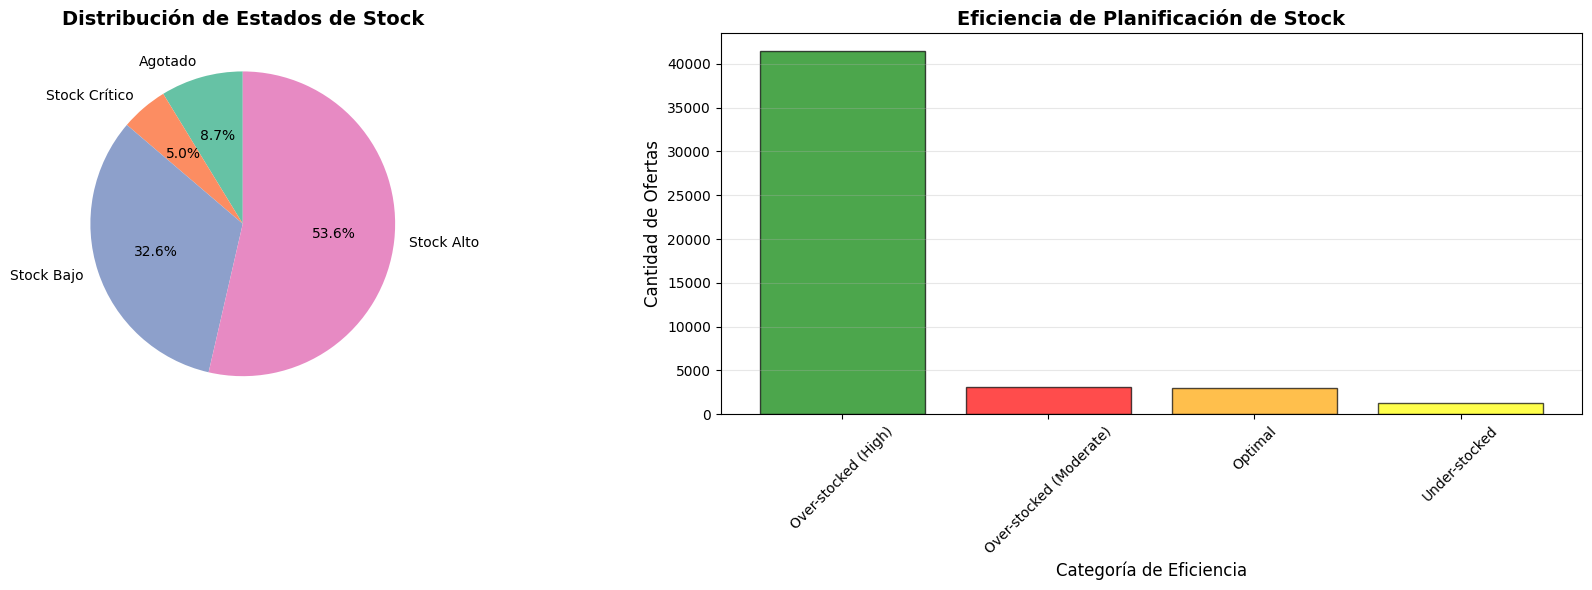


💡 INSIGHT 7: Balancear el stock evita pérdida de ventas (under-stock) y costos innecesarios (over-stock).


In [18]:
# ============================================================================
# 8. CAPÍTULO 7: OPTIMIZACIÓN DE STOCK - El balance perfecto
# ============================================================================

print("\n" + "="*80)
print("CAPÍTULO 7: OPTIMIZACIÓN DE STOCK")
print("="*80)

# Análisis de stock
df['stock_status'] = pd.cut(df['REMAINING_STOCK_AFTER_END'], 
                             bins=[-np.inf, 0, 2, 5, np.inf],
                             labels=['Agotado', 'Stock Crítico', 'Stock Bajo', 'Stock Alto'])

stock_analysis = df.groupby('stock_status').agg({
    'SOLD_AMOUNT': 'mean',
    'sell_through_rate': 'mean',
    'OFFER_START_DATE': 'count'
}).reset_index().rename(columns={'OFFER_START_DATE': 'total_offers'})

# Análisis de over/under stocking
df['stock_efficiency'] = np.where(
    df['REMAINING_STOCK_AFTER_END'] < 0, 'Under-stocked',
    np.where(df['sell_through_rate'] > 80, 'Optimal',
             np.where(df['sell_through_rate'] > 50, 'Over-stocked (Moderate)', 'Over-stocked (High)'))
)

efficiency_counts = df['stock_efficiency'].value_counts()

print(f"\n📦 ANÁLISIS DE EFICIENCIA DE STOCK:")
print(f"  • Ofertas con stock óptimo: {efficiency_counts.get('Optimal', 0):,}")
print(f"  • Ofertas con under-stocking: {efficiency_counts.get('Under-stocked', 0):,}")
print(f"  • Ofertas con over-stocking moderado: {efficiency_counts.get('Over-stocked (Moderate)', 0):,}")
print(f"  • Ofertas con over-stocking alto: {efficiency_counts.get('Over-stocked (High)', 0):,}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Distribución de stock status
axes[0].pie(stock_analysis['total_offers'], labels=stock_analysis['stock_status'], 
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
axes[0].set_title('Distribución de Estados de Stock', fontsize=14, fontweight='bold')

# Gráfico 2: Eficiencia de stock
axes[1].bar(efficiency_counts.index, efficiency_counts.values, 
            color=['green', 'red', 'orange', 'yellow'], edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Categoría de Eficiencia', fontsize=12)
axes[1].set_ylabel('Cantidad de Ofertas', fontsize=12)
axes[1].set_title('Eficiencia de Planificación de Stock', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT 7: Balancear el stock evita pérdida de ventas (under-stock) y costos innecesarios (over-stock).")

In [19]:
# ============================================================================
# 9. RESUMEN EJECUTIVO Y RECOMENDACIONES
# ============================================================================

print("\n" + "="*80)
print("RESUMEN EJECUTIVO Y RECOMENDACIONES")
print("="*80)

print(f"""
📊 HALLAZGOS CLAVE:

1. RENDIMIENTO GENERAL
   • Sell-through rate promedio: {avg_sell_through:.1f}%
   • {exhausted_pct:.1f}% de ofertas agotaron stock
   • Ingresos totales: ${total_revenue:,.2f}

2. TIMING ÓPTIMO
   • Mejor hora: {int(best_hour)}:00 hrs
   • Mejor día: {best_day}
   
3. TIPO DE OFERTA
   • Tipo más rentable: {offer_type_analysis.iloc[offer_type_analysis['SOLD_AMOUNT_sum'].idxmax()]['OFFER_TYPE']}
   
4. CATEGORÍAS TOP
   • Vertical líder: {top_verticals.iloc[0]['VERTICAL']}
   • Dominio líder: {top_domains.iloc[0]['DOM_DOMAIN_AGG1']}

5. STOCK OPTIMIZATION
   • {efficiency_counts.get('Optimal', 0):,} ofertas con stock óptimo
   • Oportunidad de mejora en {efficiency_counts.get('Over-stocked (High)', 0):,} ofertas

🎯 RECOMENDACIONES ESTRATÉGICAS:

1. TIMING: Concentrar ofertas en las ventanas horarias y días de mayor rendimiento
2. STOCK: Implementar modelo predictivo para optimizar inventario inicial
3. CATEGORIZACIÓN: Priorizar verticales y dominios de alto rendimiento
4. PRICING: Ajustar estrategia de precios según segmento objetivo
5. LOGÍSTICA: Evaluar impacto de envío gratuito en conversión

💡 PRÓXIMOS PASOS:
- Análisis de cohortes de usuarios compradores
- Modelo predictivo de sell-through rate
- A/B testing de diferentes configuraciones de oferta
- Análisis de rentabilidad por categoría
""")


RESUMEN EJECUTIVO Y RECOMENDACIONES

📊 HALLAZGOS CLAVE:

1. RENDIMIENTO GENERAL
   • Sell-through rate promedio: 41.0%
   • 8.7% de ofertas agotaron stock
   • Ingresos totales: $1,258,663.50

2. TIMING ÓPTIMO
   • Mejor hora: 13:00 hrs
   • Mejor día: Tuesday

3. TIPO DE OFERTA
   • Tipo más rentable: lightning_deal

4. CATEGORÍAS TOP
   • Vertical líder: BEAUTY & HEALTH
   • Dominio líder: PHARMACEUTICS

5. STOCK OPTIMIZATION
   • 2,977 ofertas con stock óptimo
   • Oportunidad de mejora en 41,418 ofertas

🎯 RECOMENDACIONES ESTRATÉGICAS:

1. TIMING: Concentrar ofertas en las ventanas horarias y días de mayor rendimiento
2. STOCK: Implementar modelo predictivo para optimizar inventario inicial
3. CATEGORIZACIÓN: Priorizar verticales y dominios de alto rendimiento
4. PRICING: Ajustar estrategia de precios según segmento objetivo
5. LOGÍSTICA: Evaluar impacto de envío gratuito en conversión

💡 PRÓXIMOS PASOS:
- Análisis de cohortes de usuarios compradores
- Modelo predictivo de sell-th